Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 

from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [1]:
import pandas as pd
import numpy as np

In [2]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

#2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [3]:
movie_metadata

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,...,6.0,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,...,359.0,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,...,3.0,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,...,9.0,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660


In [4]:
movie_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [5]:
numerical=movie_metadata.select_dtypes(include=['float64'])
categorical=movie_metadata.select_dtypes(include=[object])

In [6]:
categorical=categorical.astype('category')

In [7]:
movie_metadata = numerical

In [8]:
movie_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   num_critic_for_reviews   4993 non-null   float64
 1   duration                 5028 non-null   float64
 2   director_facebook_likes  4939 non-null   float64
 3   actor_3_facebook_likes   5020 non-null   float64
 4   actor_1_facebook_likes   5036 non-null   float64
 5   gross                    4159 non-null   float64
 6   facenumber_in_poster     5030 non-null   float64
 7   num_user_for_reviews     5022 non-null   float64
 8   budget                   4551 non-null   float64
 9   title_year               4935 non-null   float64
 10  actor_2_facebook_likes   5030 non-null   float64
 11  imdb_score               5043 non-null   float64
 12  aspect_ratio             4714 non-null   float64
dtypes: float64(13)
memory usage: 512.3 KB


In [9]:
X= movie_metadata.drop(columns='imdb_score')
y= movie_metadata.imdb_score

#3 Check for missing variables and correct as needed.

In [10]:
movie_metadata.isna().sum()

num_critic_for_reviews      50
duration                    15
director_facebook_likes    104
actor_3_facebook_likes      23
actor_1_facebook_likes       7
gross                      884
facenumber_in_poster        13
num_user_for_reviews        21
budget                     492
title_year                 108
actor_2_facebook_likes      13
imdb_score                   0
aspect_ratio               329
dtype: int64

In [11]:
#drop rows with missing data
movie_metadata=movie_metadata.dropna()

In [12]:
import pandas as pd

# Categorize imdb_score into two classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 7.5 else "average"
)

# Check the value counts
print(movie_metadata["imdb_score"].value_counts())

imdb_score
average    3157
high        644
Name: count, dtype: int64


/tmp/ipykernel_859/1158005314.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(


#4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

#5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [13]:
#calculate the prevalence
print(644/3157)

0.2039911308203991


This number means that the possibility of predicting a movie with a high imdb score is 0.204.

## 6 Split your data into test, tune, and train. (80/10/10)

In [14]:
X= movie_metadata.drop(columns='imdb_score')
y= movie_metadata.imdb_score

In [18]:
from sklearn.preprocessing import OrdinalEncoder
movie_metadata[["imdb_score"]] = OrdinalEncoder().fit_transform(movie_metadata[["imdb_score"]])
print(movie_metadata["imdb_score"].value_counts())

imdb_score
0.0    3157
1.0     644
Name: count, dtype: int64


/tmp/ipykernel_859/3757408107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie_metadata[["imdb_score"]] = OrdinalEncoder().fit_transform(movie_metadata[["imdb_score"]])


In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state=49)

## 7 Create the kfold object for cross validation.

In [20]:
from sklearn.model_selection import RepeatedStratifiedKFold

kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

## 8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter 

In [21]:
scoring = ['roc_auc','recall','balanced_accuracy']

## 9 Build the classifier object 

In [22]:
param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}

In [23]:
from sklearn.preprocessing import LabelEncoder

# Convert target variable to numerical labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)  # Do the same for test data if applicable

print(le.classes_)  # Check label encoding mapping

['average' 'high']


In [ ]:
cl= DecisionTreeClassifier(random_state=1000)

#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')

#execute search on our training data, this may take a few seconds ...
model = search.fit(X_train, y_train)

## 10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [45]:
#Retrieve the best estimator out of all parameters passed, based on highest roc_auc
best = model.best_estimator_
print(best) #depth of 6

DecisionTreeClassifier(max_depth=6, random_state=1000)


## 11 Fit the model to the training data.

## 12 What is the best depth value?

6

In [46]:
#What about the specific scores (roc_auc, recall, balanced_accuracy)? Let's try and extract them to see what we are working with ...
print(model.cv_results_) #This is a dictionary and in order to extract info we need the keys

{'mean_fit_time': array([0.0086264 , 0.0116379 , 0.0144593 , 0.01657818, 0.02436553,
       0.03066995, 0.03360001, 0.03302218, 0.03287082, 0.03214654,
       0.03308961]), 'std_fit_time': array([0.00390796, 0.00442584, 0.0037247 , 0.00373875, 0.00812627,
       0.019536  , 0.01977764, 0.01099932, 0.0069981 , 0.00807253,
       0.004414  ]), 'mean_score_time': array([0.01278035, 0.00966823, 0.01148798, 0.00978509, 0.01205863,
       0.01523643, 0.01353351, 0.0127311 , 0.00895746, 0.00775509,
       0.00781441]), 'std_score_time': array([0.00504171, 0.00314709, 0.00620522, 0.00444939, 0.00544391,
       0.0184427 , 0.00785663, 0.00772097, 0.00350028, 0.00267811,
       0.00384196]), 'param_max_depth': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value=999999), 'params': [{'max_depth': 1}, {'max_depth': 2}, {'max_depth': 3}, {'max_depth': 4}, {'max_dep

In [47]:
print(model.cv_results_.keys()) #get mean_test and std_test for all of our scores, and will need our param_max_depth as well 

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'params', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'split5_test_roc_auc', 'split6_test_roc_auc', 'split7_test_roc_auc', 'split8_test_roc_auc', 'split9_test_roc_auc', 'split10_test_roc_auc', 'split11_test_roc_auc', 'split12_test_roc_auc', 'split13_test_roc_auc', 'split14_test_roc_auc', 'split15_test_roc_auc', 'split16_test_roc_auc', 'split17_test_roc_auc', 'split18_test_roc_auc', 'split19_test_roc_auc', 'split20_test_roc_auc', 'split21_test_roc_auc', 'split22_test_roc_auc', 'split23_test_roc_auc', 'split24_test_roc_auc', 'split25_test_roc_auc', 'split26_test_roc_auc', 'split27_test_roc_auc', 'split28_test_roc_auc', 'split29_test_roc_auc', 'split30_test_roc_auc', 'split31_test_roc_auc', 'split32_test_roc_auc', 'split33_test_roc_auc', 'split34_test_roc_auc', 'split35_test_roc_auc', 'split36_test_roc_auc', 'split37_tes

In [49]:
#Let's extract these scores, using our function!

#Scores: 

auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

#Parameter:
depth= np.unique(model.cv_results_['param_max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.682392,0.000000,0.500000,0.038108,0.000000,0.000000
2,0.731773,0.116164,0.556181,0.034968,0.048237,0.023069
3,0.763168,0.229652,0.600880,0.034602,0.092131,0.039277
4,0.786312,0.280715,0.618990,0.036233,0.086054,0.034712
5,0.796097,0.312145,0.634887,0.036348,0.065986,0.030998
6,0.799217,0.371565,0.660023,0.037189,0.082631,0.040004
7,0.785460,0.390319,0.664105,0.044419,0.071810,0.034711
8,0.758694,0.427449,0.679865,0.053268,0.073859,0.035648
9,0.724738,0.443391,0.684303,0.058638,0.075302,0.034763
10,0.706207,0.467778,0.693828,0.061317,0.082846,0.039584


## 13 Print out the model

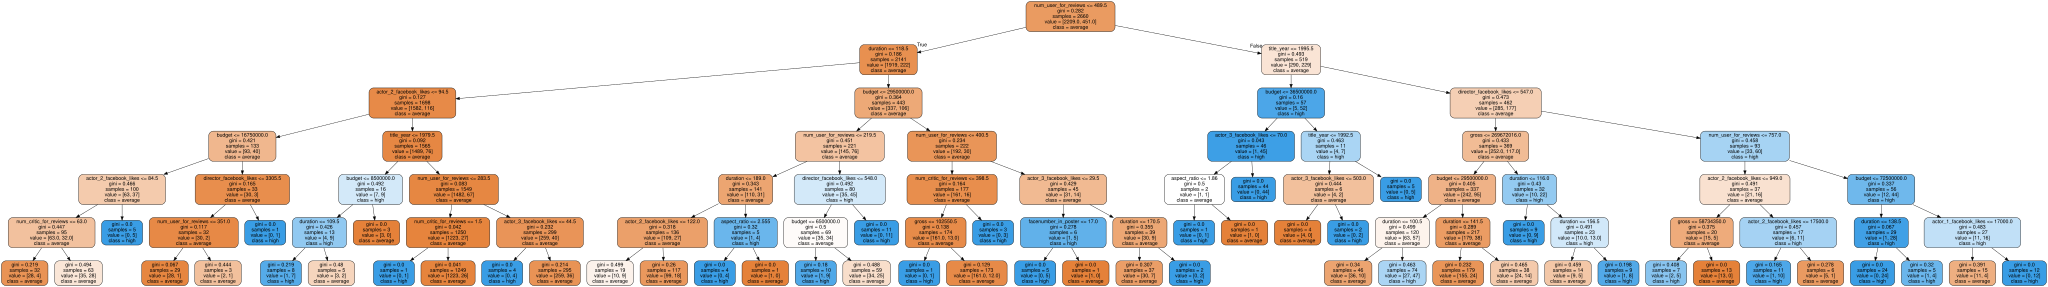

In [42]:
dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns, #feature names from dataset
               filled=True, 
                rounded=True, 
                class_names = ['average','high']) #classification labels 
               
graph=graphviz.Source(dot_data)
graph

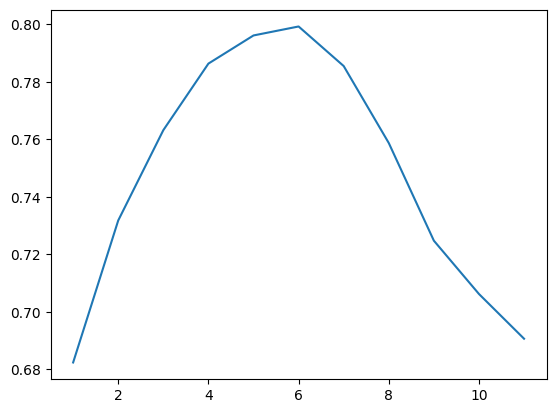

In [50]:
print(plt.plot(final_model.depth,final_model.auc)) #5 does in fact have the highest (best) AUC!

#14 View the results, comment on how the model performed using several evaluation metrics.

#15 Which variables appear to be contributing the most (variable importance) 

In [51]:
#Variable importance for the best estimator, how much weight does each feature have in determining the classification?
varimp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                         importance
num_user_for_reviews       0.346902
duration                   0.133145
budget                     0.111866
title_year                 0.111254
actor_2_facebook_likes     0.085579
director_facebook_likes    0.063786
gross                      0.045148
actor_3_facebook_likes     0.038093
num_critic_for_reviews     0.031916
actor_1_facebook_likes     0.020257
aspect_ratio               0.007345
facenumber_in_poster       0.004709


Number of users for reviews is the most important feature.

Axes(0.125,0.11;0.775x0.77)


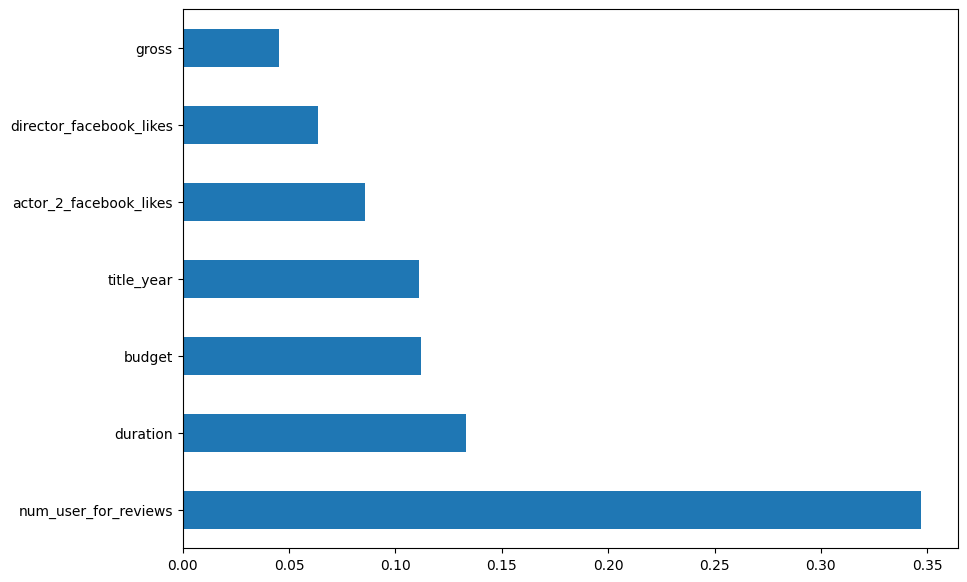

In [52]:
#Graph variable importance
plt.figure(figsize=(10,7))
print(varimp.importance.nlargest(7).plot(kind='barh')) #Alcohol has the largest impact by far!

#16 Use the predict method on the test data and print out the results.

#17 How does the model perform on the test data?

In [58]:
print(best.score(X_test,y_test)) #Pretty precise, nice!

0.8563922942206655


#18 Print out the confusion matrix for the test data, what does it tell you about the model?

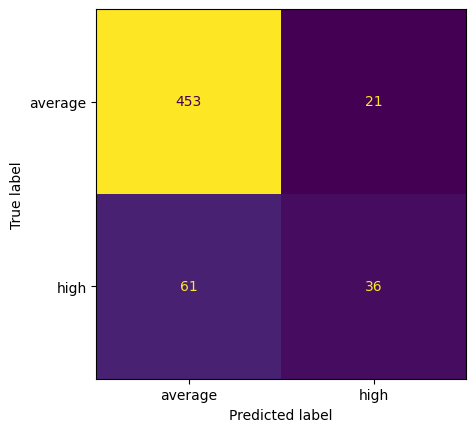

In [57]:
print(ConfusionMatrixDisplay.from_estimator(best,X_test,y_test, display_labels = ['average','high'], colorbar=False))

#19 What are the top 3 movies based on the test set? Which variables are most important in predicting the top 3 movies?

In [60]:
y_pred = model.predict(X_test)
#['predicted_score'] = y_pred
#top_movies = .sort_values(by='predicted_score', ascending=False).head(3)
#print(top_movies[['movie_title', 'predicted_score']])

#20 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.